#**DSBDAL Assignment 1**

Name: Sharv Mahajan

Roll No.: 31430

####Importing libraries

In [ ]:
import pandas as pd


#### Load Dataset
[Dataset Link](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [ ]:
df = pd.read_csv('diabetes.csv')

### DataFrame Information

In [ ]:
print(df.shape)

(768, 9)


In [ ]:
display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Initial Data Analysis

In [ ]:
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Introducing Missing Values
Here we introduce missing values (NaN) because we want to use interpolation techniques to fill the missing values.

In [ ]:
import numpy as np

# Columns to introduce missing values into
cols = ['Glucose', 'BloodPressure', 'BMI', 'Insulin']

# Percentage of values to replace with NaN (e.g., 5%)
percentage_null = 0.05

for col in cols:
    # Get random indices to replace with NaN
    num_nulls = int(len(df) * percentage_null)
    null_indices = np.random.choice(df.index, num_nulls, replace=False)
    df.loc[null_indices, col] = np.nan

print(f"Successfully introduced {percentage_null * 100}% missing values into columns: {', '.join(cols)}.")

Successfully introduced 5.0% missing values into columns: Glucose, BloodPressure, BMI, Insulin.


### Updated Missing Value Count

In [ ]:
print(df.isnull().sum())

Pregnancies                  0
Glucose                     38
BloodPressure               38
SkinThickness                0
Insulin                     38
BMI                         38
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64


In [ ]:
df = df.interpolate().ffill()
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
missing_row_Glucose = df[df['Glucose'].isnull()]
display(missing_row_Glucose)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [ ]:
mean_glucose = df['Glucose'].mean()
df['Glucose'] = df['Glucose'].fillna(mean_glucose)
print(f"Filled missing 'Glucose' value with mean: {mean_glucose:.2f}")
print(df.isnull().sum())

Filled missing 'Glucose' value with mean: 120.81
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
print(df.dtypes)

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


## Generate Histograms for all Columns

Creating histogram for easy visualization


### Histograms for Individuals with Diabetes (Outcome = 1)

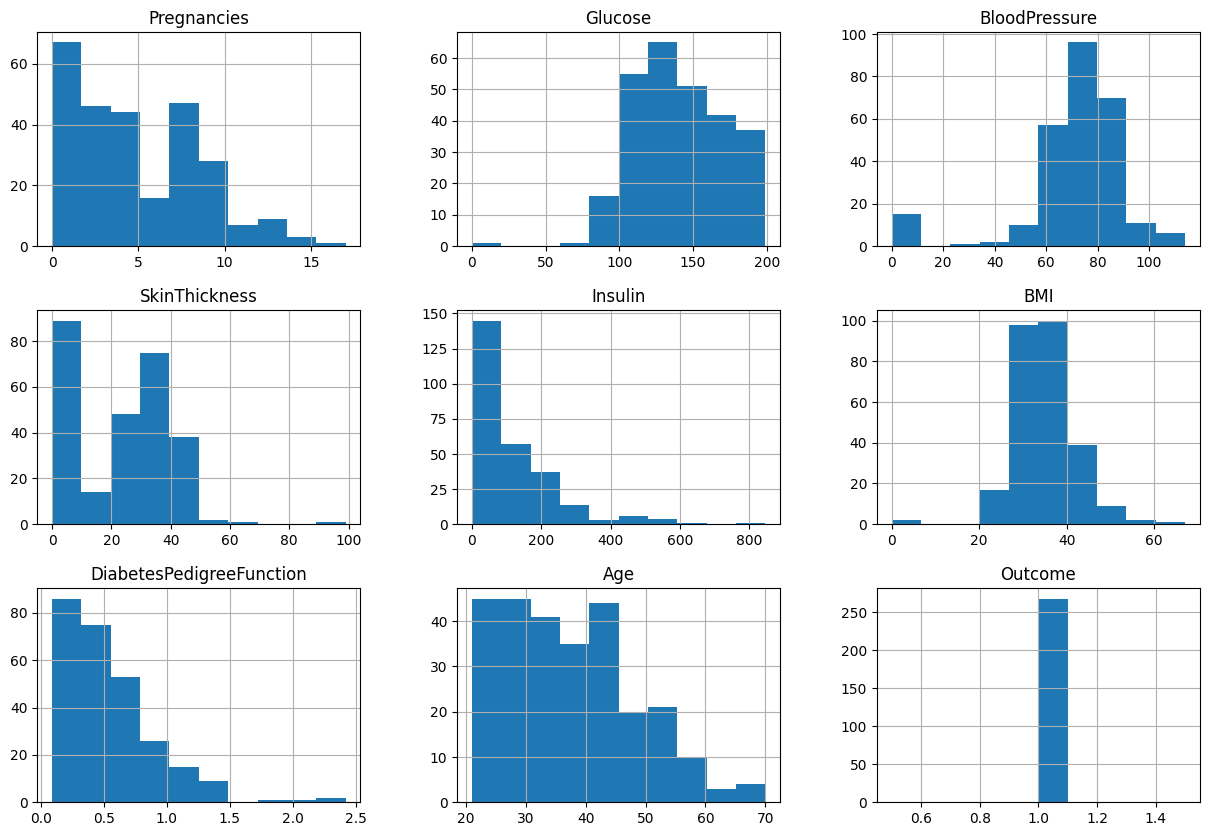

In [ ]:
import matplotlib.pyplot as plt

diabetic_df = df[df['Outcome'] == 1]
diabetic_df.hist(figsize=(15, 10))
plt.show()



---





---



### Histograms for Individuals Without Diabetes (Outcome = 0)

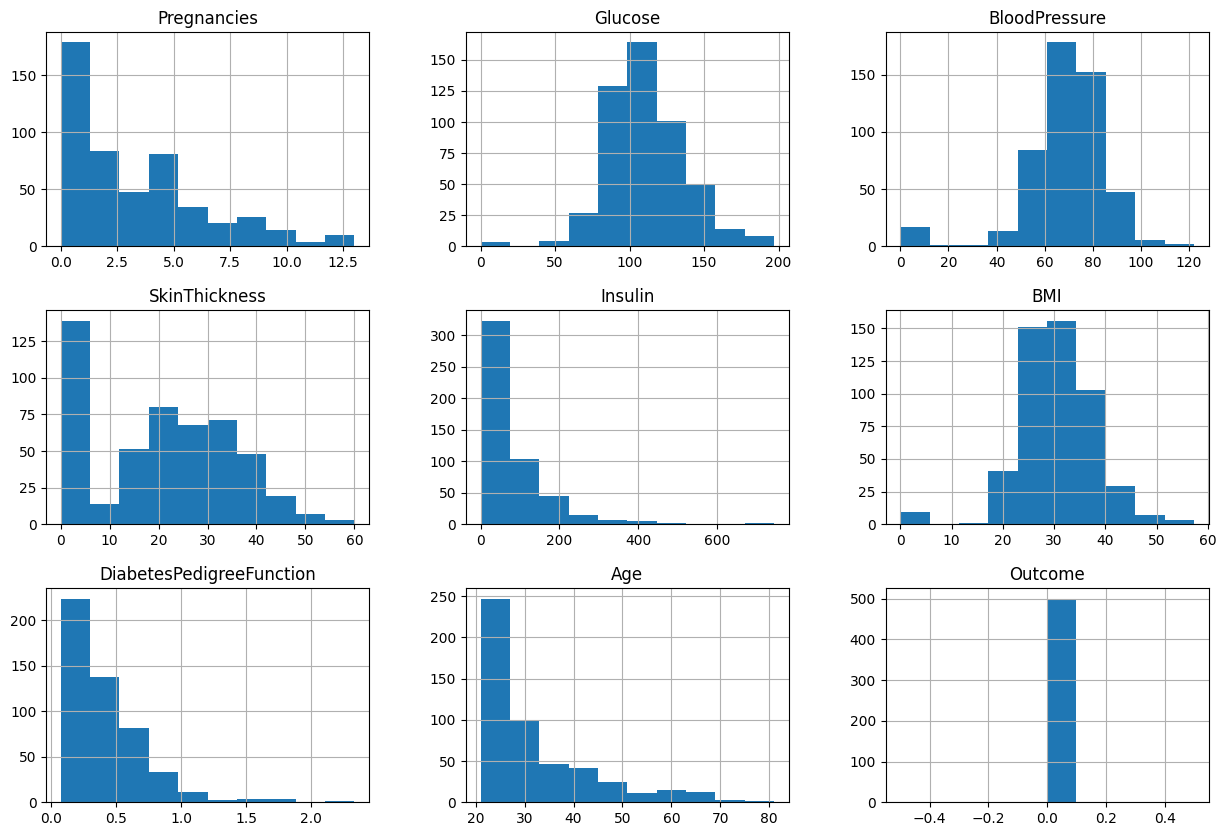

In [ ]:
non_diabetic_df = df[df['Outcome'] == 0]
non_diabetic_df.hist(figsize=(15, 10))
plt.show()